# Industry Employment Growth (2016 → 2025)

Which industries grew employment most during the inflationary period?

Datasets: #1 employment by industry, #2 average prices (used as an inflation benchmark).

Industries and their seasonally-adjusted CES series:

| Industry | Series ID |
|---|---|
| Construction | CES2000000001 |
| Manufacturing | CES3000000001 |
| Retail | CES4200000001 |
| Healthcare | CES6562000001 |
| Leisure & Hospitality | CES7000000001 |
| Professional Services | CES6054000001 |

In [1]:
# plotting and data-wrangling libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Employment (Dataset #1)

Reshape to long form. Values are in thousands; `CES` = seasonally adjusted. Reused from `eda.ipynb`.

In [2]:
# load the raw earnings table (wide: one column per month)
earn = pd.read_csv('Dataset #1 - earnings.txt')
earn = earn.rename(columns={'Series ID': 'series_id'})
earn.shape

(348, 133)

In [3]:
# reshape wide -> long: one row per series-month
earn_long = earn.melt(id_vars=['series_id'], var_name='month', value_name='employment')
earn_long.head()

,series_id,month,employment
0,CEU0000000001,Jan 2016,141073.0
1,CES0000000001,Jan 2016,143210.0
2,CEU0500000001,Jan 2016,119093.0
3,CES0500000001,Jan 2016,121096.0
4,CEU0600000001,Jan 2016,19238.0


In [4]:
# parse month strings to dates; strip the '(P)' preliminary tag and force numeric
earn_long['month'] = pd.to_datetime(earn_long['month'], format='%b %Y', errors='coerce')
earn_long['employment'] = pd.to_numeric(
    earn_long['employment'].astype(str).str.replace(r'\(P\)', '', regex=True).str.strip(),
    errors='coerce')
earn_long.head()

,series_id,month,employment
0,CEU0000000001,2016-01-01,141073.0
1,CES0000000001,2016-01-01,143210.0
2,CEU0500000001,2016-01-01,119093.0
3,CES0500000001,2016-01-01,121096.0
4,CEU0600000001,2016-01-01,19238.0


In [5]:
# drop empty rows (blanks/future months) and flag seasonally-adjusted (CES) series
earn_long = earn_long.dropna(subset=['month', 'employment'])
earn_long['adjusted'] = earn_long['series_id'].str.startswith('CES')
print('rows:', len(earn_long))
print('date range:', earn_long['month'].min().date(), '->', earn_long['month'].max().date())
earn_long.head()

rows: 43152
date range: 2016-01-01 -> 2026-04-01


,series_id,month,employment,adjusted
0,CEU0000000001,2016-01-01,141073.0,False
1,CES0000000001,2016-01-01,143210.0,True
2,CEU0500000001,2016-01-01,119093.0,False
3,CES0500000001,2016-01-01,121096.0,True
4,CEU0600000001,2016-01-01,19238.0,False


## 2. Inflation (Dataset #2)

Same reshape, used later as an economy-wide price benchmark. Reused from `eda.ipynb`.

In [6]:
# map each price series ID to a readable item name
labels = {}
with open('inflation_ids.txt') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        label, code = line.rsplit(' - ', 1)
        labels[code.strip()] = label.strip()
len(labels)

15

In [7]:
# load prices and attach the item names
inf = pd.read_csv('Dataset #2 - inflation.txt')
inf = inf.rename(columns={'Series ID': 'series_id'})
inf['item'] = inf['series_id'].map(labels)
inf[['series_id', 'item']].head()

,series_id,item
0,APU0000704111,"Bacon, sliced, per lb."
1,APU0000711211,"Bananas, per lb."
2,APU0000702111,"Bread, white, pan, per lb."
3,APU0000706111,"Chicken, fresh, whole, per lb."
4,APU0000717311,"Coffee, 100%, ground roast, all sizes, per lb."


In [8]:
# reshape wide -> long and coerce blanks/placeholders to NaN
inf_long = inf.melt(id_vars=['series_id', 'item'], var_name='month', value_name='price')
inf_long['month'] = pd.to_datetime(inf_long['month'], format='%b %Y', errors='coerce')
inf_long['price'] = pd.to_numeric(inf_long['price'], errors='coerce')
inf_long = inf_long.dropna(subset=['month', 'price'])
print('rows:', len(inf_long), '| items:', inf_long['item'].nunique())
inf_long.head()

rows: 1814 | items: 15


,series_id,item,month,price
0,APU0000704111,"Bacon, sliced, per lb.",2016-01-01,5.656
1,APU0000711211,"Bananas, per lb.",2016-01-01,0.581
2,APU0000702111,"Bread, white, pan, per lb.",2016-01-01,1.425
3,APU0000706111,"Chicken, fresh, whole, per lb.",2016-01-01,1.429
4,APU0000717311,"Coffee, 100%, ground roast, all sizes, per lb.",2016-01-01,4.498


## 3. Pick the six industries

In [9]:
# series ID -> industry label
industries = {
    'CES2000000001': 'Construction',
    'CES3000000001': 'Manufacturing',
    'CES4200000001': 'Retail',
    'CES6562000001': 'Healthcare',
    'CES7000000001': 'Leisure & Hospitality',
    'CES6054000001': 'Professional Services',
}
industries

{'CES2000000001': 'Construction',
 'CES3000000001': 'Manufacturing',
 'CES4200000001': 'Retail',
 'CES6562000001': 'Healthcare',
 'CES7000000001': 'Leisure & Hospitality',
 'CES6054000001': 'Professional Services'}

In [10]:
# keep only those series; tag each row with its label and year
ind = earn_long[earn_long['series_id'].isin(industries)].copy()
ind['industry'] = ind['series_id'].map(industries)
ind['year'] = ind['month'].dt.year
ind.head()

,series_id,month,employment,adjusted,industry,year
25,CES2000000001,2016-01-01,6631.0,True,Construction,2016
41,CES3000000001,2016-01-01,12354.0,True,Manufacturing,2016
111,CES4200000001,2016-01-01,15664.8,True,Retail,2016
213,CES6054000001,2016-01-01,8810.8,True,Professional Services,2016
263,CES6562000001,2016-01-01,18838.1,True,Healthcare,2016


In [11]:
# confirm all six industries are present
sorted(ind['industry'].unique())

['Construction',
 'Healthcare',
 'Leisure & Hospitality',
 'Manufacturing',
 'Professional Services',
 'Retail']

In [12]:
# employment range per industry (thousands)
ind.groupby('industry')['employment'].agg(['min', 'max'])

,min,max
industry,,
Construction,6522.0,8321.0
Healthcare,18485.0,23808.5
Leisure & Hospitality,8719.0,16978.0
Manufacturing,11382.0,12903.0
Professional Services,8810.8,10820.6
Retail,13246.9,15872.6


## 4. Percent growth, 2016 → 2025

Compare calendar-year average employment in 2025 vs 2016 to smooth seasonality. The inflation benchmark applies the same calculation to each item's price and averages across the basket.

In [13]:
# average employment per industry per year
annual = ind.groupby(['industry', 'year'])['employment'].mean().reset_index()
annual.head()

,industry,year,employment
0,Construction,2016,6726.666667
1,Construction,2017,6967.083333
2,Construction,2018,7288.333333
3,Construction,2019,7493.083333
4,Construction,2020,7255.416667


In [14]:
# pull the 2016 and 2025 yearly averages
emp_2016 = annual[annual['year'] == 2016].set_index('industry')['employment']
emp_2025 = annual[annual['year'] == 2025].set_index('industry')['employment']
emp_2025

industry
Construction              8263.333333
Healthcare               23290.950000
Leisure & Hospitality    16869.416667
Manufacturing            12632.250000
Professional Services    10776.808333
Retail                   15441.516667
Name: employment, dtype: float64

In [15]:
# percent change 2016 -> 2025, largest first
emp_growth = (100 * (emp_2025 / emp_2016 - 1)).rename('employment_growth_pct')
emp_growth.sort_values(ascending=False)

industry
Construction             22.844400
Healthcare               22.131739
Professional Services    21.366605
Leisure & Hospitality     7.730420
Manufacturing             2.505376
Retail                   -2.150906
Name: employment_growth_pct, dtype: float64

In [16]:
# inflation benchmark: same percent change per item, averaged across the basket
inf_y = inf_long.copy()
inf_y['year'] = inf_y['month'].dt.year
item_annual = inf_y.groupby(['item', 'year'])['price'].mean()
item_growth = 100 * (item_annual.xs(2025, level='year') / item_annual.xs(2016, level='year') - 1)
inflation_benchmark = item_growth.mean()
print(f'inflation benchmark (basket avg, 2016->2025): {inflation_benchmark:.1f}%')

inflation benchmark (basket avg, 2016->2025): 45.2%


In [17]:
# ranked table with the gap vs inflation in percentage points
summary = emp_growth.sort_values(ascending=False).round(1).to_frame()
summary['vs_inflation_pp'] = (summary['employment_growth_pct'] - inflation_benchmark).round(1)
summary

,employment_growth_pct,vs_inflation_pp
industry,,
Construction,22.8,-22.4
Healthcare,22.1,-23.1
Professional Services,21.4,-23.8
Leisure & Hospitality,7.7,-37.5
Manufacturing,2.5,-42.7
Retail,-2.2,-47.4


## 5. Grouped bar chart

Industries sorted by employment growth, each paired against the inflation benchmark.

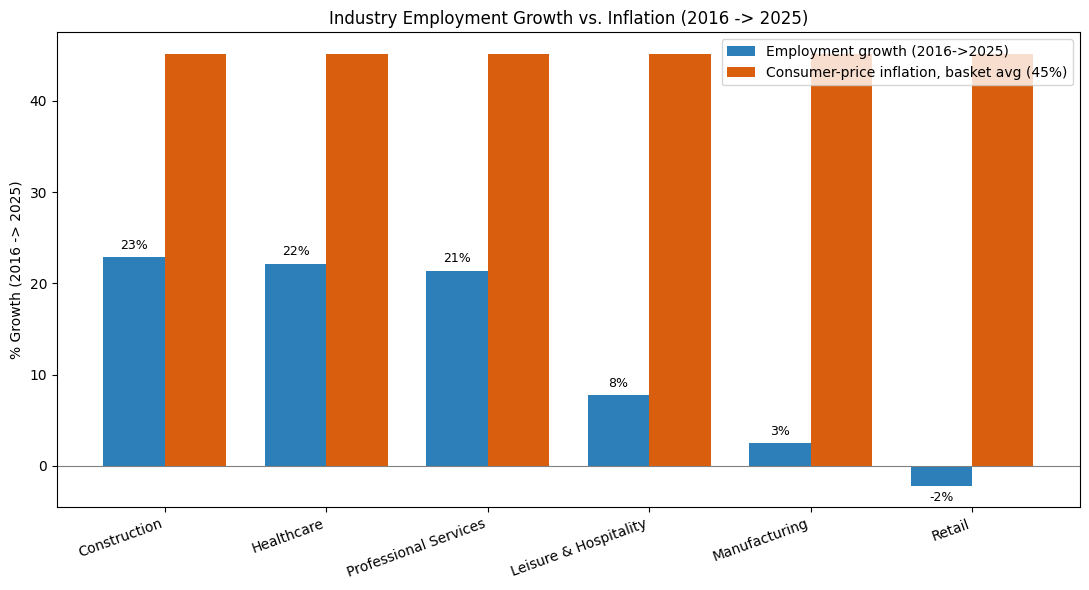

In [18]:
# sort industries by growth (largest first)
order = emp_growth.sort_values(ascending=False).index
vals = emp_growth[order].values
x = np.arange(len(order))
w = 0.38  # bar width; offset the two bars left/right of each tick

fig, ax = plt.subplots(figsize=(11, 6))
# blue: per-industry employment growth
ax.bar(x - w / 2, vals, w, label='Employment growth (2016->2025)', color='#2c7fb8')
# orange: the same inflation benchmark repeated for each industry
ax.bar(x + w / 2, [inflation_benchmark] * len(order), w,
       label=f'Consumer-price inflation, basket avg ({inflation_benchmark:.0f}%)', color='#d95f0e')

ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=20, ha='right')
ax.set_ylabel('% Growth (2016 -> 2025)')
ax.set_title('Industry Employment Growth vs. Inflation (2016 -> 2025)')
ax.legend()

# label each employment bar with its value
for xi, v in zip(x, vals):
    ax.text(xi - w / 2, v + (0.6 if v >= 0 else -0.6), f'{v:.0f}%',
            ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)

fig.tight_layout()
plt.show()

## 6. Takeaways

Employment growth, 2016 → 2025:

| Industry | Growth |
|---|---|
| Construction | +22.8% |
| Healthcare | +22.1% |
| Professional Services | +21.4% |
| Leisure & Hospitality | +7.7% |
| Manufacturing | +2.5% |
| Retail | −2.2% |